# 🏦 Bank Marketing Campaign
## ⚡ Model 4: XGBoost

XGBoost (Extreme Gradient Boosting) is one of
the most powerful machine learning algorithms.
It builds trees sequentially, where each tree
corrects the errors of the previous one.

It predicts whether a customer will
subscribe to a term deposit or not.

#Install & Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1: Load Data

Loading the preprocessed data:

train.csv → Training data (after SMOTE) : (63870, 48)
test.csv  → Testing data (original)     : (9042, 48)

In [ ]:
# Load Data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("✅ Data loaded successfully!")
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

✅ Data loaded successfully!
Train Shape: (63870, 48)
Test Shape: (9042, 48)


## ✂️ Step 2: Split Data

Splitting data into Features (X) and Target (y):

X_train → Features for training
y_train → Target for training
X_test  → Features for testing
y_test  → Target for testing

In [ ]:
# Split Features and Target
X_train = train.drop('y', axis=1)
y_train = train['y']

X_test = test.drop('y', axis=1)
y_test = test['y']

print("✅ Split done successfully!")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

✅ Split done successfully!
X_train: (63870, 47)
y_train: (63870,)
X_test: (9042, 47)
y_test: (9042,)


## ⚡ Step 3: Train XGBoost Model

Training the XGBoost Classifier
on the training data.

In [ ]:
from xgboost import XGBClassifier

# Train Model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print("✅ XGBoost trained successfully!")

✅ XGBoost trained successfully!


## 📊 Step 4: Model Evaluation

Evaluating the model on the test data
using Classification Report.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Accuracy: 0.8824375138243752

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7984
           1       0.50      0.42      0.46      1058

    accuracy                           0.88      9042
   macro avg       0.71      0.68      0.70      9042
weighted avg       0.88      0.88      0.88      9042



## 🔢 Step 5: Confusion Matrix

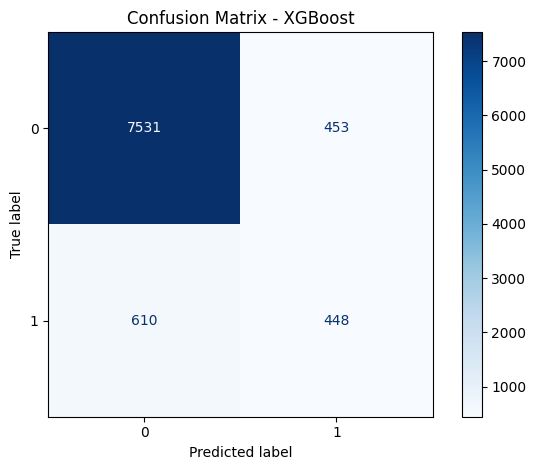

✅ Confusion Matrix saved!


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=150)
plt.show()

print("✅ Confusion Matrix saved!")

## 📈 Step 6: ROC Curve & AUC Score

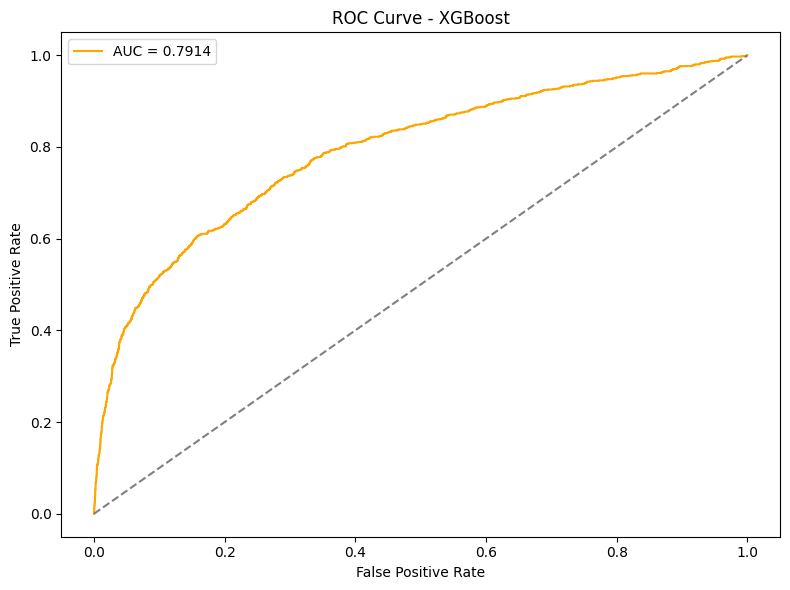

✅ AUC Score: 0.7914


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
y_prob = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_xgb.png', dpi=150)
plt.show()

print(f"✅ AUC Score: {auc_score:.4f}")